In [1]:
import numpy
import cv2
import matplotlib

print("numpy", numpy.__version__)
print("cv2", cv2.__version__)
print("matplotlib", matplotlib.__version__)

numpy 1.26.4
cv2 4.13.0
matplotlib 3.9.2


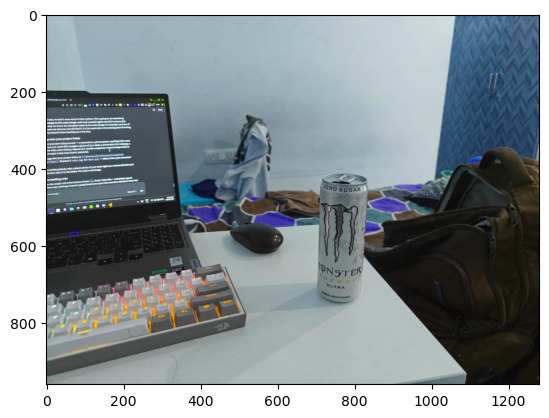

In [2]:
import cv2
import matplotlib.pyplot as plt
image = cv2.imread("main.png")
plt.imshow(image)
plt.show()

In [3]:
print("Type:", type(image))
print("Shape:", image.shape)
print("Data type:", image.dtype)
print("Top-left pixel (BGR):", image[0, 0])


Type: <class 'numpy.ndarray'>
Shape: (960, 1280, 3)
Data type: uint8
Top-left pixel (BGR): [158 179 187]


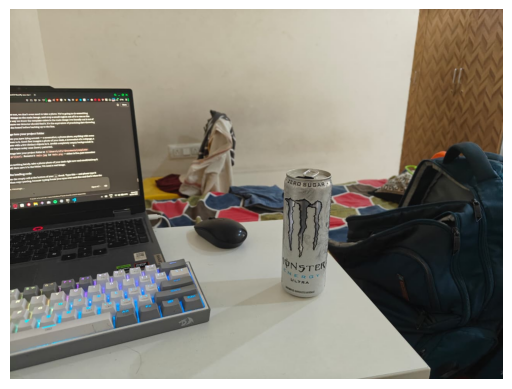

In [4]:
# Convert from BGR (OpenCV's convention) to RGB (everyone else's convention)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis("off")  # hide the pixel-coordinate ticks for a cleaner look
plt.show()

Template shape: (299, 101, 3)


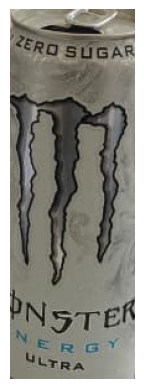

In [5]:
top_left_x = 716
top_left_y = 421
bottom_right_x = 817
bottom_right_y = 720

template = image[top_left_y:bottom_right_y, top_left_x:bottom_right_x]

print("Template shape:", template.shape)

template_rgb = cv2.cvtColor(template, cv2.COLOR_BGR2RGB)
plt.imshow(template_rgb)
plt.axis("off")
plt.show()

Main image gray shape: (960, 1280)
Template gray shape: (299, 101)


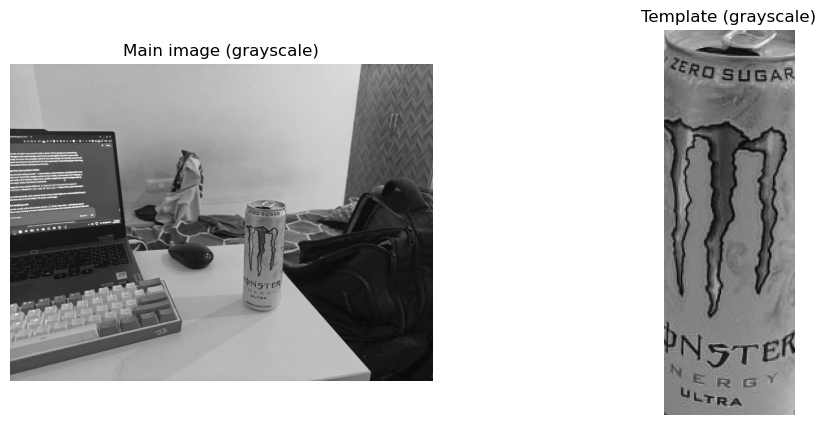

In [6]:
# Convert both images to grayscale
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

print("Main image gray shape:", image_gray.shape)
print("Template gray shape:", template_gray.shape)

# Display them side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_gray, cmap="gray")
axes[0].set_title("Main image (grayscale)")
axes[0].axis("off")
axes[1].imshow(template_gray, cmap="gray")
axes[1].set_title("Template (grayscale)")
axes[1].axis("off")
plt.show()

In [7]:
import numpy as np

def ncc(patch1, patch2):
    """
    Compute Normalized Cross-Correlation between two equal-sized patches.
    Returns a value in [-1, +1]. Higher = more similar.
    """
    # Convert to float so the math doesn't overflow uint8's 0-255 range
    p1 = patch1.astype(np.float64)
    p2 = patch2.astype(np.float64)

    # Subtract the mean from each patch
    p1_centered = p1 - p1.mean()
    p2_centered = p2 - p2.mean()

    # Numerator: sum of element-wise products
    numerator = np.sum(p1_centered * p2_centered)

    # Denominator: square root of (sum of squares of each, multiplied)
    denominator = np.sqrt(np.sum(p1_centered ** 2) * np.sum(p2_centered ** 2))

    # Guard against division by zero (uniform patches have zero variance)
    if denominator == 0:
        return 0.0

    return numerator / denominator

In [8]:
# Two patches with the same pattern but different brightness
# Image patch is uniformly 50 brighter than template
patch_image = np.array([
    [100, 200],
    [100, 200]
], dtype=np.uint8)

patch_template = np.array([
    [50, 150],
    [50, 150]
], dtype=np.uint8)

score = ncc(patch_image, patch_template)
print(f"Same pattern, different brightness: NCC = {score}")

Same pattern, different brightness: NCC = 1.0


In [9]:
# Opposite patterns: template's bright where image is dark
patch_image_2 = np.array([
    [100, 200],
    [100, 200]
], dtype=np.uint8)

patch_template_2 = np.array([
    [150, 50],
    [150, 50]
], dtype=np.uint8)

score = ncc(patch_image_2, patch_template_2)
print(f"Opposite pattern: NCC = {score}")

Opposite pattern: NCC = -1.0


In [10]:
def sliding_ncc(main, template):
    """
    Slide the template across the main image, computing NCC at every position.
    Returns a 2D response map where each value is the NCC score at that
    position (top-left of where the template was placed).
    """
    main_h, main_w = main.shape
    tmpl_h, tmpl_w = template.shape

    # The number of valid top-left positions
    out_h = main_h - tmpl_h + 1
    out_w = main_w - tmpl_w + 1

    # Pre-allocate the response map with zeros
    response = np.zeros((out_h, out_w), dtype=np.float64)

    # Slide
    for y in range(out_h):
        for x in range(out_w):
            patch = main[y:y + tmpl_h, x:x + tmpl_w]
            response[y, x] = ncc(patch, template)
        # Print progress every 50 rows so we know it's alive
        if y % 50 == 0:
            print(f"  Row {y} / {out_h}")

    return response

In [11]:
import time

print("Starting sliding NCC...")
start = time.time()

response_map = sliding_ncc(image_gray, template_gray)

elapsed = time.time() - start
print(f"Done in {elapsed:.1f} seconds")
print(f"Response map shape: {response_map.shape}")
print(f"Max NCC score: {response_map.max():.4f}")
print(f"Min NCC score: {response_map.min():.4f}")

Starting sliding NCC...
  Row 0 / 662
  Row 50 / 662
  Row 100 / 662
  Row 150 / 662
  Row 200 / 662
  Row 250 / 662
  Row 300 / 662
  Row 350 / 662
  Row 400 / 662
  Row 450 / 662
  Row 500 / 662
  Row 550 / 662
  Row 600 / 662
  Row 650 / 662
Done in 187.7 seconds
Response map shape: (662, 1180)
Max NCC score: 1.0000
Min NCC score: -0.3397


In [12]:
# Find the position of the maximum value in the response map
# np.argmax returns a single index into the FLATTENED array
# np.unravel_index converts that into 2D (row, column) coordinates
max_pos_flat = np.argmax(response_map)
max_y, max_x = np.unravel_index(max_pos_flat, response_map.shape)

print(f"Peak NCC location (top-left of best match): x={max_x}, y={max_y}")
print(f"Peak NCC score: {response_map[max_y, max_x]:.4f}")
print(f"Original crop coords were: x={top_left_x}, y={top_left_y}")

Peak NCC location (top-left of best match): x=716, y=421
Peak NCC score: 1.0000
Original crop coords were: x=716, y=421


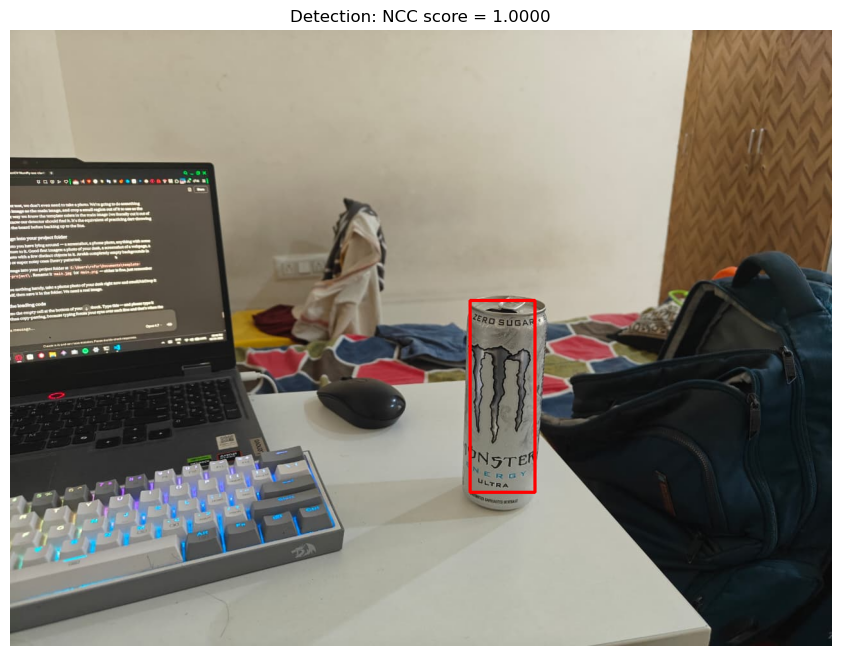

In [13]:
# Make a copy of the RGB image so we don't draw on the original
output = image_rgb.copy()

# Get template dimensions for drawing the rectangle
tmpl_h, tmpl_w = template_gray.shape

# cv2.rectangle takes (image, top_left_pt, bottom_right_pt, color, thickness)
# Coordinates here are (x, y) format — OpenCV-style, not NumPy-style
top_left = (max_x, max_y)
bottom_right = (max_x + tmpl_w, max_y + tmpl_h)
cv2.rectangle(output, top_left, bottom_right, color=(255, 0, 0), thickness=4)

# Display
plt.figure(figsize=(12, 8))
plt.imshow(output)
plt.title(f"Detection: NCC score = {response_map[max_y, max_x]:.4f}")
plt.axis("off")
plt.show()

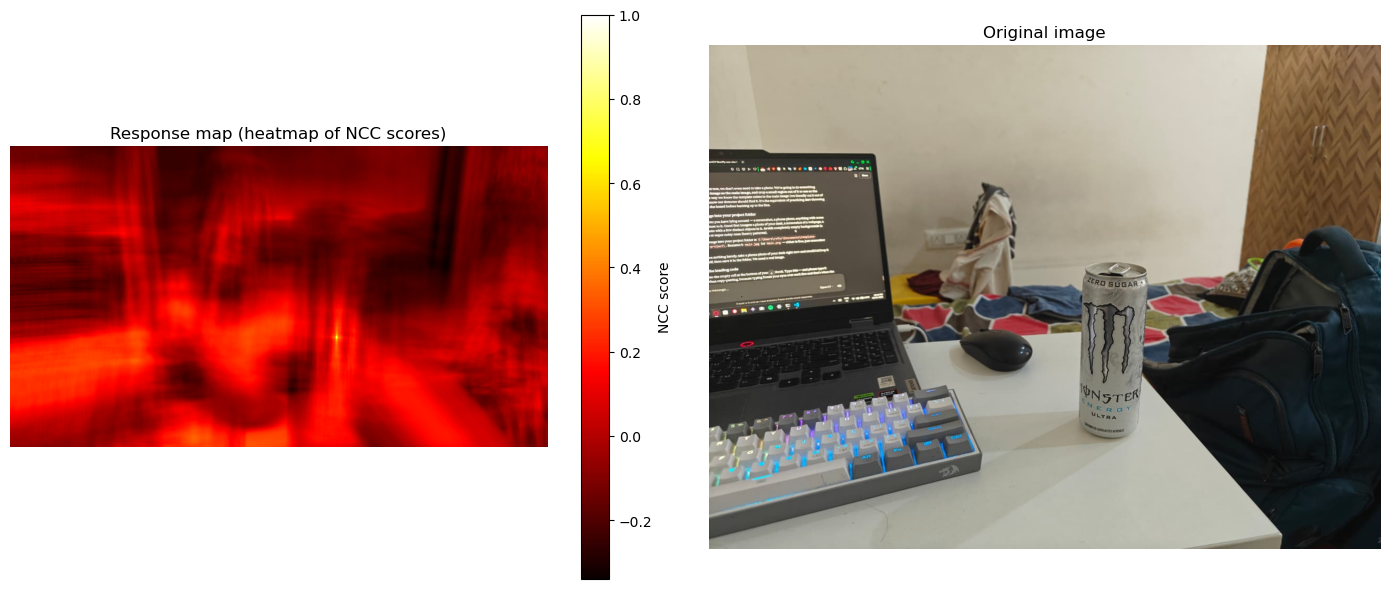

In [14]:
plt.figure(figsize=(14, 6))

# Left: the response map as a heatmap
plt.subplot(1, 2, 1)
plt.imshow(response_map, cmap="hot")
plt.colorbar(label="NCC score")
plt.title("Response map (heatmap of NCC scores)")
plt.axis("off")

# Right: the original image for comparison
plt.subplot(1, 2, 2)
plt.imshow(image_rgb)
plt.title("Original image")
plt.axis("off")

plt.tight_layout()
plt.show()

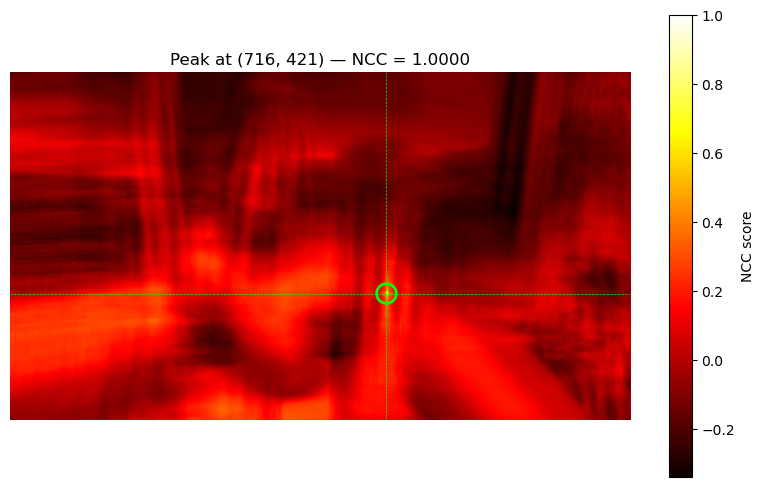

In [15]:
plt.figure(figsize=(10, 6))
plt.imshow(response_map, cmap="hot")
plt.colorbar(label="NCC score")

# Mark the peak with a green crosshair
plt.axhline(y=max_y, color='lime', linewidth=0.5, linestyle='--')
plt.axvline(x=max_x, color='lime', linewidth=0.5, linestyle='--')
plt.scatter([max_x], [max_y], s=200, edgecolor='lime', facecolor='none', linewidth=2)

plt.title(f"Peak at ({max_x}, {max_y}) — NCC = {response_map[max_y, max_x]:.4f}")
plt.axis("off")
plt.show()

In [16]:
import time

# Run OpenCV's optimized version
start = time.time()
opencv_response = cv2.matchTemplate(image_gray, template_gray, cv2.TM_CCOEFF_NORMED)
opencv_elapsed = time.time() - start

print(f"OpenCV time: {opencv_elapsed:.4f} seconds")
print(f"Your time:   172.4 seconds (from earlier)")
print(f"Speedup:     {172.4 / opencv_elapsed:.0f}x faster")
print()
print(f"OpenCV response map shape: {opencv_response.shape}")
print(f"Your response map shape:   {response_map.shape}")

# Find OpenCV's peak
opencv_max_pos = np.unravel_index(np.argmax(opencv_response), opencv_response.shape)
opencv_max_y, opencv_max_x = opencv_max_pos

print()
print(f"Your peak:    x={max_x}, y={max_y}, score={response_map[max_y, max_x]:.4f}")
print(f"OpenCV peak:  x={opencv_max_x}, y={opencv_max_y}, score={opencv_response[opencv_max_y, opencv_max_x]:.4f}")

OpenCV time: 0.0520 seconds
Your time:   172.4 seconds (from earlier)
Speedup:     3316x faster

OpenCV response map shape: (662, 1180)
Your response map shape:   (662, 1180)

Your peak:    x=716, y=421, score=1.0000
OpenCV peak:  x=716, y=421, score=1.0000


Original:  (960, 1280)
Half:      (480, 640)
Quarter:   (240, 320)
Eighth:    (120, 160)


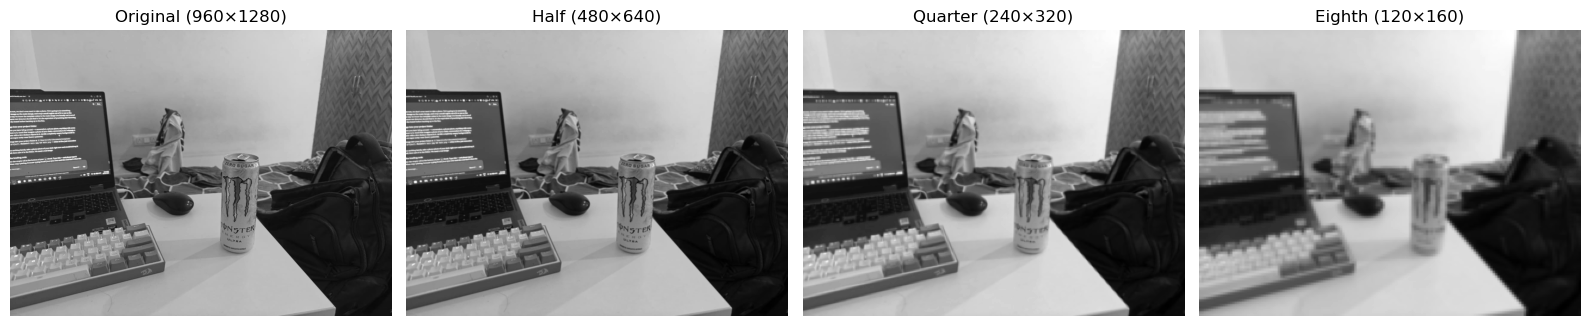

In [17]:
def shrink_by_half(img):
    """
    Shrink an image to half its dimensions using Gaussian blur + downsample.
    This is the proper anti-aliased shrink, not naive subsampling.
    """
    return cv2.pyrDown(img)


# Test it
half = shrink_by_half(image_gray)
quarter = shrink_by_half(half)
eighth = shrink_by_half(quarter)

print(f"Original:  {image_gray.shape}")
print(f"Half:      {half.shape}")
print(f"Quarter:   {quarter.shape}")
print(f"Eighth:    {eighth.shape}")

# Visualize all four side by side
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, img, title in zip(
    axes,
    [image_gray, half, quarter, eighth],
    ["Original (960×1280)", "Half (480×640)", "Quarter (240×320)", "Eighth (120×160)"]
):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [18]:
def build_pyramid(img, num_levels):
    """
    Build an image pyramid: a list of progressively smaller versions of the image.
    
    pyramid[0] is the original (largest).
    pyramid[-1] is the smallest (deepest level).
    
    Each level is half the height and half the width of the previous.
    """
    pyramid = [img]  # start with the original
    
    for _ in range(num_levels - 1):
        smaller = shrink_by_half(pyramid[-1])  # shrink the most-recent level
        pyramid.append(smaller)
    
    return pyramid


# Build pyramids for both image and template
image_pyramid = build_pyramid(image_gray, num_levels=3)
template_pyramid = build_pyramid(template_gray, num_levels=3)

print("Image pyramid:")
for i, level in enumerate(image_pyramid):
    print(f"  Level {i}: shape {level.shape}")

print()
print("Template pyramid:")
for i, level in enumerate(template_pyramid):
    print(f"  Level {i}: shape {level.shape}")

Image pyramid:
  Level 0: shape (960, 1280)
  Level 1: shape (480, 640)
  Level 2: shape (240, 320)

Template pyramid:
  Level 0: shape (299, 101)
  Level 1: shape (150, 51)
  Level 2: shape (75, 26)


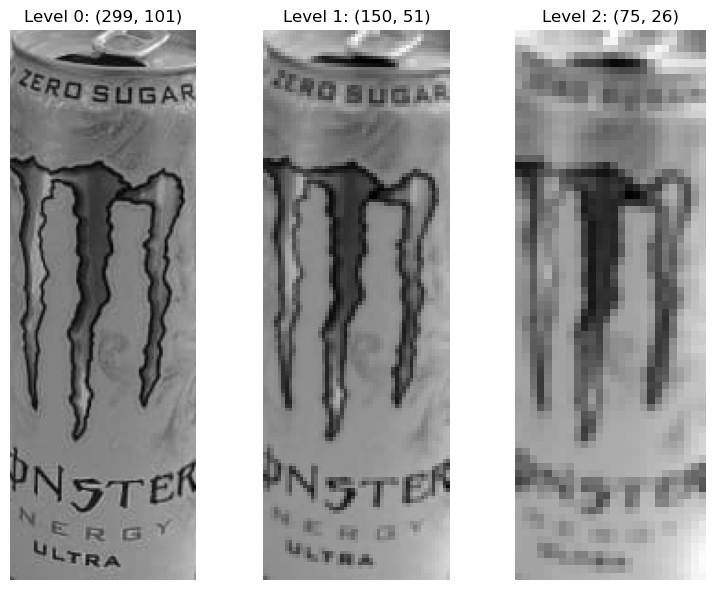

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(8, 6))
for i, (ax, level) in enumerate(zip(axes, template_pyramid)):
    ax.imshow(level, cmap="gray")
    ax.set_title(f"Level {i}: {level.shape}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [20]:
def refine_peak(main, template, rough_y, rough_x, window_radius=10):
    """
    Search a small window around (rough_y, rough_x) for the best NCC match.
    Returns the refined (y, x) of the best position and the score.
    """
    main_h, main_w = main.shape
    tmpl_h, tmpl_w = template.shape
    
    # Define the search window's bounds, clamped to valid positions
    # Valid top-left positions are 0 to (main_h - tmpl_h) inclusive
    y_min = max(0, rough_y - window_radius)
    y_max = min(main_h - tmpl_h, rough_y + window_radius)
    x_min = max(0, rough_x - window_radius)
    x_max = min(main_w - tmpl_w, rough_x + window_radius)
    
    best_score = -np.inf  # start with the worst possible score
    best_y, best_x = rough_y, rough_x
    
    for y in range(y_min, y_max + 1):
        for x in range(x_min, x_max + 1):
            patch = main[y:y + tmpl_h, x:x + tmpl_w]
            score = ncc(patch, template)
            if score > best_score:
                best_score = score
                best_y, best_x = y, x
    
    return best_y, best_x, best_score

In [21]:
def pyramid_match(image, template, num_levels=3, window_radius=10):
    """
    Coarse-to-fine template matching using an image pyramid.
    Returns the (y, x) of the best match in the original image and its score.
    """
    # Build pyramids
    image_pyr = build_pyramid(image, num_levels)
    template_pyr = build_pyramid(template, num_levels)
    
    # ---- Step 1: full search at the smallest level ----
    smallest_image = image_pyr[-1]
    smallest_template = template_pyr[-1]
    
    print(f"Level {num_levels - 1} (smallest): full search "
          f"on {smallest_image.shape} image, {smallest_template.shape} template")
    
    response = sliding_ncc(smallest_image, smallest_template)
    flat_idx = np.argmax(response)
    rough_y, rough_x = np.unravel_index(flat_idx, response.shape)
    rough_score = response[rough_y, rough_x]
    
    print(f"  Peak at level {num_levels - 1}: ({rough_y}, {rough_x}) score={rough_score:.4f}")
    
    # ---- Step 2: refine at each successively larger level ----
    for level in range(num_levels - 2, -1, -1):  # count down: e.g. 1, 0
        # Scale rough coordinates up by 2 (because each level is half-size)
        rough_y *= 2
        rough_x *= 2
        
        print(f"Level {level}: refining around ({rough_y}, {rough_x}) "
              f"with window radius {window_radius}")
        
        rough_y, rough_x, rough_score = refine_peak(
            image_pyr[level],
            template_pyr[level],
            rough_y, rough_x,
            window_radius=window_radius
        )
        
        print(f"  Refined to ({rough_y}, {rough_x}) score={rough_score:.4f}")
    
    return rough_y, rough_x, rough_score

In [22]:
import time

print("=== Pyramid coarse-to-fine matching ===")
start = time.time()

py_y, py_x, py_score = pyramid_match(image_gray, template_gray, num_levels=3)

elapsed = time.time() - start

print()
print(f"Pyramid time:    {elapsed:.2f} seconds")
print(f"Brute force was: 172.4 seconds")
print(f"Speedup:         {172.4 / elapsed:.1f}x")
print()
print(f"Pyramid result:  x={py_x}, y={py_y}, score={py_score:.4f}")
print(f"Brute force was: x={max_x}, y={max_y}, score={response_map[max_y, max_x]:.4f}")

=== Pyramid coarse-to-fine matching ===
Level 2 (smallest): full search on (240, 320) image, (75, 26) template
  Row 0 / 166
  Row 50 / 166
  Row 100 / 166
  Row 150 / 166
  Peak at level 2: (105, 179) score=0.9869
Level 1: refining around (210, 358) with window radius 10
  Refined to (211, 358) score=0.9699
Level 0: refining around (422, 716) with window radius 10
  Refined to (421, 716) score=1.0000

Pyramid time:    2.48 seconds
Brute force was: 172.4 seconds
Speedup:         69.6x

Pyramid result:  x=716, y=421, score=1.0000
Brute force was: x=716, y=421, score=1.0000


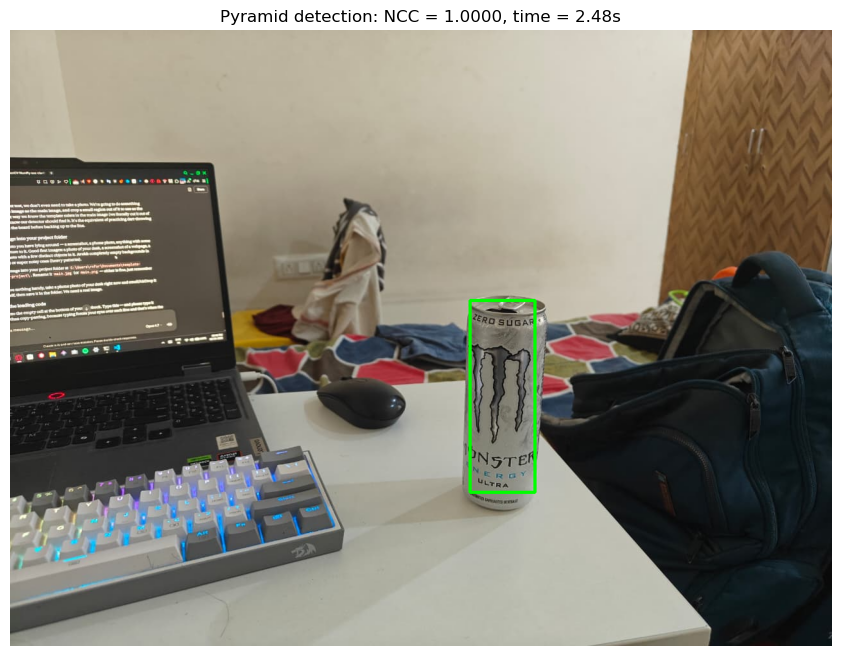

In [23]:
# Visualize the pyramid detection result
output = image_rgb.copy()
tmpl_h, tmpl_w = template_gray.shape

top_left = (py_x, py_y)
bottom_right = (py_x + tmpl_w, py_y + tmpl_h)
cv2.rectangle(output, top_left, bottom_right, color=(0, 255, 0), thickness=4)

plt.figure(figsize=(12, 8))
plt.imshow(output)
plt.title(f"Pyramid detection: NCC = {py_score:.4f}, time = 2.48s")
plt.axis("off")
plt.show()

In [24]:
# Reload the module fresh in case we edit it later
%load_ext autoreload
%autoreload 2

# Import everything we need
from template_matcher import (
    ncc,
    sliding_ncc,
    shrink_by_half,
    build_pyramid,
    refine_peak,
    pyramid_match,
)

print("Module imported successfully")

Module imported successfully


In [25]:
import time

start = time.time()
final_y, final_x, final_score = pyramid_match(
    image_gray, template_gray, num_levels=3, window_radius=10, verbose=True
)
elapsed = time.time() - start

print()
print(f"Result: x={final_x}, y={final_y}, score={final_score:.4f}")
print(f"Time:   {elapsed:.2f}s")

Level 2 (smallest): full search on (240, 320) image, (75, 26) template
  Peak at level 2: (105, 179) score=0.9869
Level 1: refining around (210, 358) with window radius 10
  Refined to (211, 358) score=0.9699
Level 0: refining around (422, 716) with window radius 10
  Refined to (421, 716) score=1.0000

Result: x=716, y=421, score=1.0000
Time:   2.40s


In [26]:
def run_experiment(modified_image_gray, modified_image_rgb, experiment_name):
    """
    Run pyramid_match on a modified image, visualize the result, and return the score.
    """
    import time
    
    start = time.time()
    y, x, score = pyramid_match(modified_image_gray, template_gray, num_levels=3)
    elapsed = time.time() - start
    
    # Draw the bounding box
    output = modified_image_rgb.copy()
    tmpl_h, tmpl_w = template_gray.shape
    cv2.rectangle(
        output,
        (x, y),
        (x + tmpl_w, y + tmpl_h),
        color=(0, 255, 0),
        thickness=4,
    )
    
    # Display
    plt.figure(figsize=(10, 6))
    plt.imshow(output)
    plt.title(f"{experiment_name} — NCC = {score:.4f}, time = {elapsed:.2f}s")
    plt.axis("off")
    plt.show()
    
    print(f"  Detection at: x={x}, y={y}")
    print(f"  Score: {score:.4f}")
    
    return score

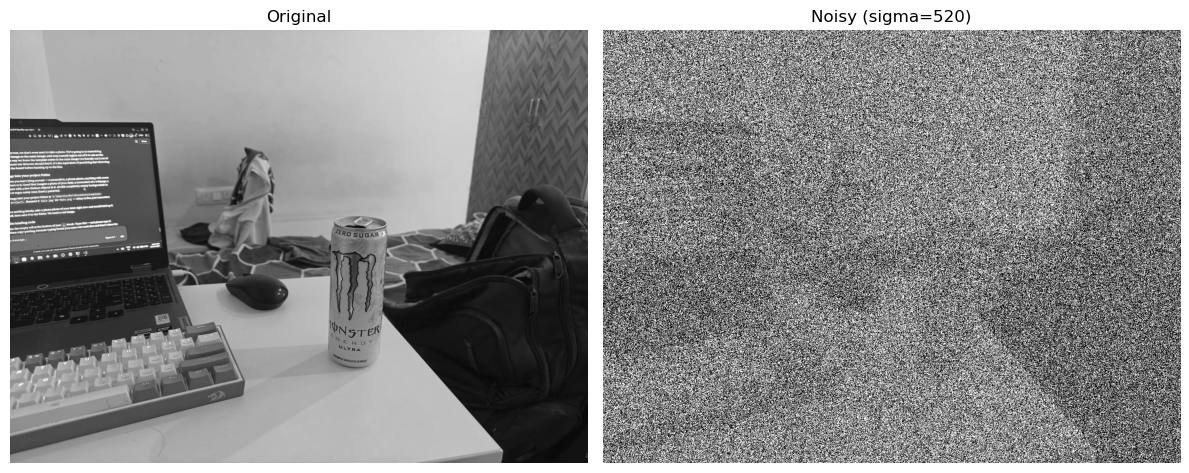

In [51]:
# Add Gaussian noise to the image
# Noise is sampled from a normal distribution with std-dev = noise_strength
noise_strength = 520  # try changing this later: 10 (mild), 30 (medium), 60 (heavy), 100 (severe)

# np.random.normal generates random numbers from a normal distribution
noise = np.random.normal(0, noise_strength, image_gray.shape)

# Add the noise; clip to keep values in valid 0-255 range; cast back to uint8
noisy_gray = np.clip(image_gray.astype(np.float64) + noise, 0, 255).astype(np.uint8)

# Make an RGB version for visualization
noisy_rgb = cv2.cvtColor(noisy_gray, cv2.COLOR_GRAY2RGB)

# Show what we just did
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_gray, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(noisy_gray, cmap="gray")
axes[1].set_title(f"Noisy (sigma={noise_strength})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

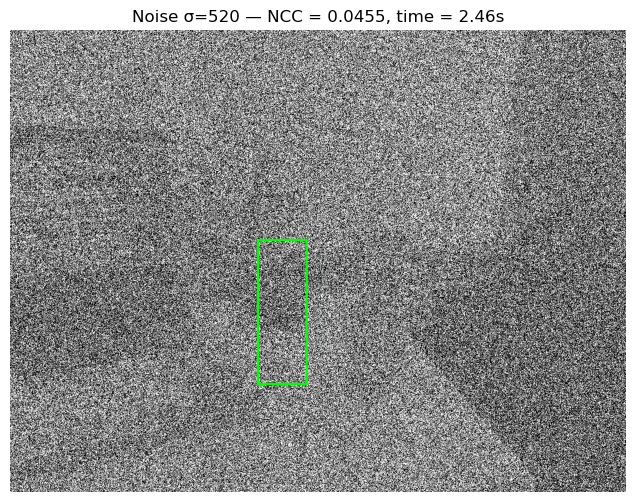

  Detection at: x=515, y=436
  Score: 0.0455


In [52]:
score_noisy = run_experiment(noisy_gray, noisy_rgb, f"Noise σ={noise_strength}")

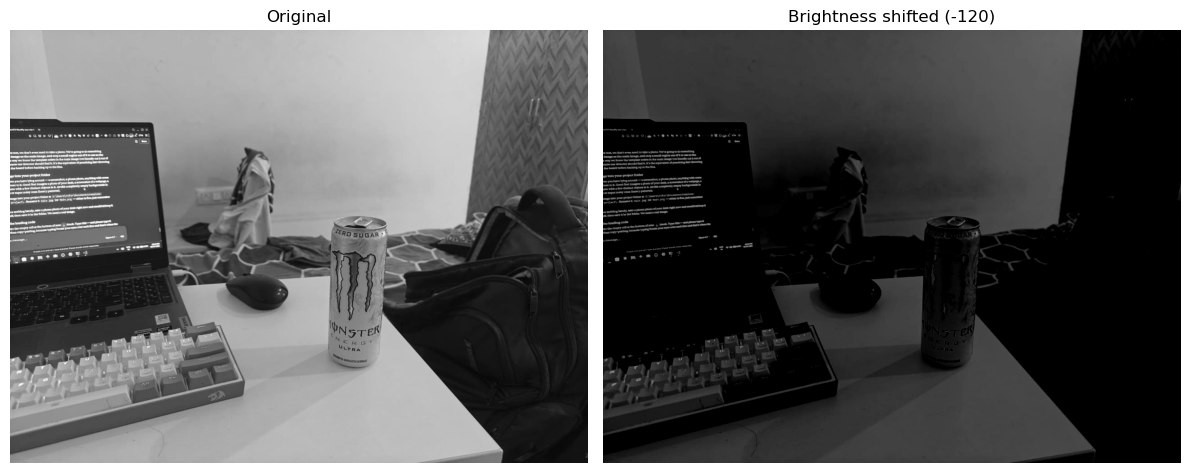

In [57]:
# Make the image uniformly darker by subtracting a constant from every pixel
brightness_shift = -120  # negative = darker, positive = brighter
                        # try later: -120 (very dark), +80 (brighter), +120 (very bright)

# Apply the shift, clip to valid range, cast back to uint8
shifted_gray = np.clip(
    image_gray.astype(np.float64) + brightness_shift, 0, 255
).astype(np.uint8)

shifted_rgb = cv2.cvtColor(shifted_gray, cv2.COLOR_GRAY2RGB)

# Show clean vs shifted side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(shifted_gray, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Brightness shifted ({brightness_shift:+d})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

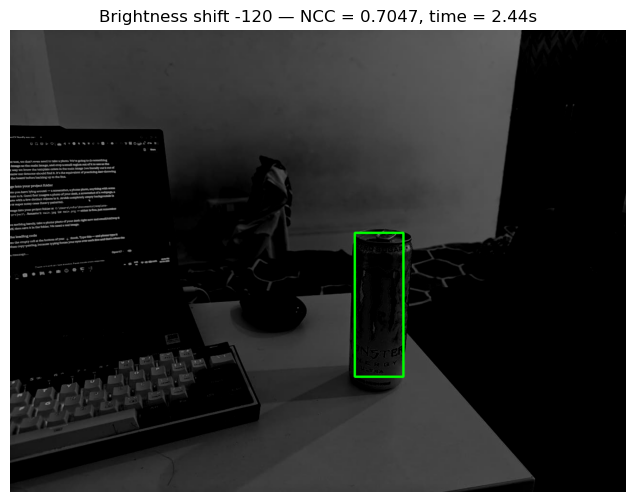

  Detection at: x=716, y=421
  Score: 0.7047


In [58]:
score_shifted = run_experiment(
    shifted_gray, shifted_rgb, f"Brightness shift {brightness_shift:+d}"
)

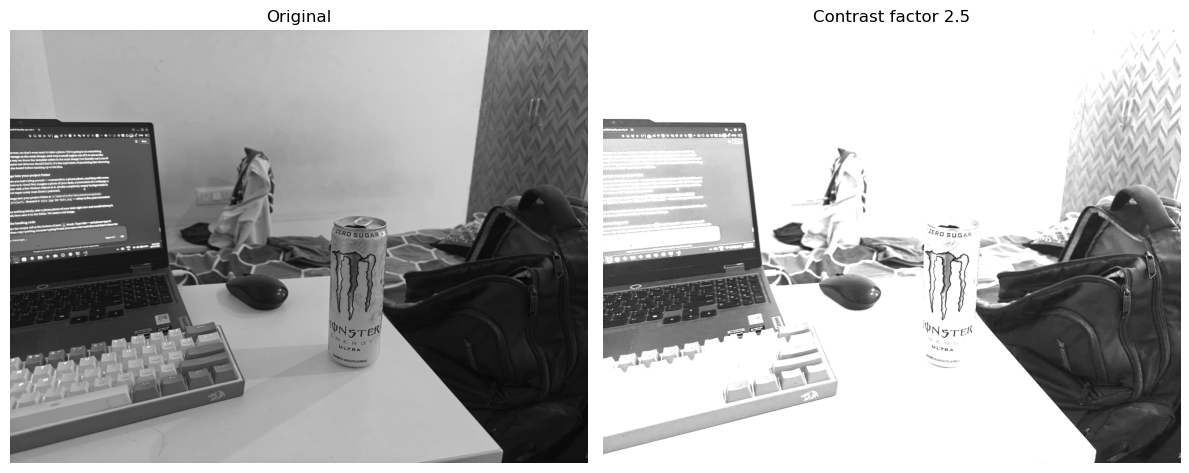

In [61]:
# Apply a contrast change by multiplying every pixel by a factor
contrast_factor = 2.5  # 0.5 = washed out (half contrast)
                       # try later: 0.3 (very low contrast), 1.5 (boosted), 2.5 (extreme)

# Multiply, clip to valid range, cast back to uint8
contrast_gray = np.clip(
    image_gray.astype(np.float64) * contrast_factor, 0, 255
).astype(np.uint8)

contrast_rgb = cv2.cvtColor(contrast_gray, cv2.COLOR_GRAY2RGB)

# Show clean vs contrast-changed side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(contrast_gray, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Contrast factor {contrast_factor}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

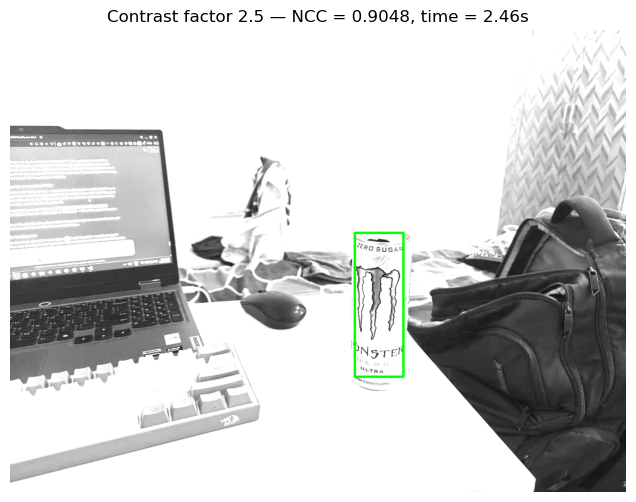

  Detection at: x=716, y=421
  Score: 0.9048


In [62]:
score_contrast = run_experiment(
    contrast_gray, contrast_rgb, f"Contrast factor {contrast_factor}"
)

Original size: (960, 1280)
Scaled size:   (672, 896)


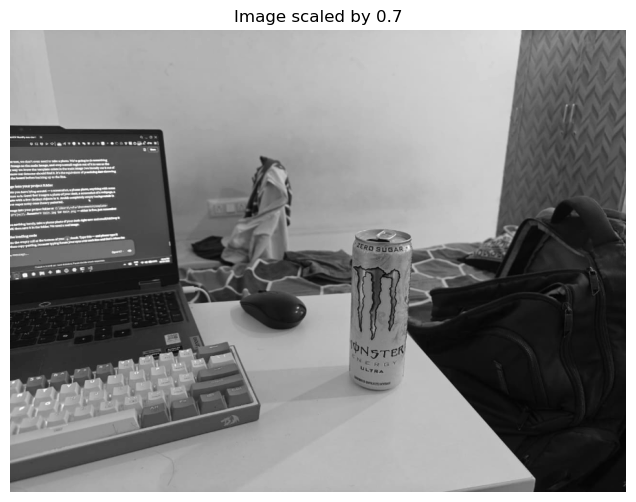

In [63]:
# Resize the image to a different scale
# scale < 1 makes the image smaller; scale > 1 makes it bigger
scale = 0.7  # try later: 0.5 (half size), 0.85 (slightly smaller), 1.3 (bigger), 1.5 (much bigger)

new_h = int(image_gray.shape[0] * scale)
new_w = int(image_gray.shape[1] * scale)

scaled_gray = cv2.resize(image_gray, (new_w, new_h))
scaled_rgb = cv2.cvtColor(scaled_gray, cv2.COLOR_GRAY2RGB)

print(f"Original size: {image_gray.shape}")
print(f"Scaled size:   {scaled_gray.shape}")

plt.figure(figsize=(10, 6))
plt.imshow(scaled_gray, cmap="gray")
plt.title(f"Image scaled by {scale}")
plt.axis("off")
plt.show()

Original size: (960, 1280)
Scaled size:   (384, 512)


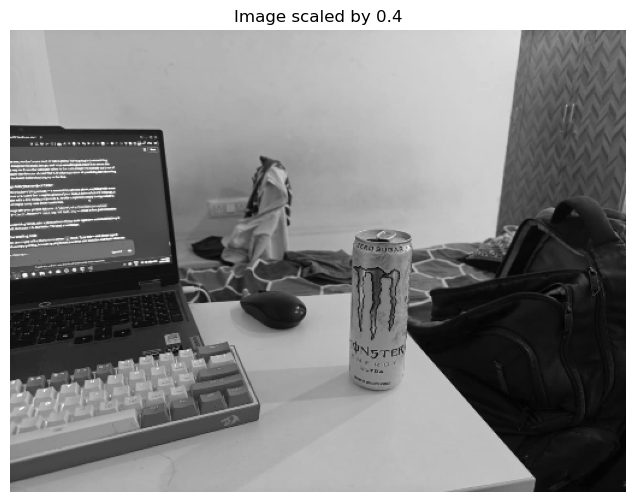

In [68]:
# Resize the image to a different scale
# scale < 1 makes the image smaller; scale > 1 makes it bigger
scale = 0.4  # try later: 0.5 (half size), 0.85 (slightly smaller), 1.3 (bigger), 1.5 (much bigger)

new_h = int(image_gray.shape[0] * scale)
new_w = int(image_gray.shape[1] * scale)

scaled_gray = cv2.resize(image_gray, (new_w, new_h))
scaled_rgb = cv2.cvtColor(scaled_gray, cv2.COLOR_GRAY2RGB)

print(f"Original size: {image_gray.shape}")
print(f"Scaled size:   {scaled_gray.shape}")

plt.figure(figsize=(10, 6))
plt.imshow(scaled_gray, cmap="gray")
plt.title(f"Image scaled by {scale}")
plt.axis("off")
plt.show()

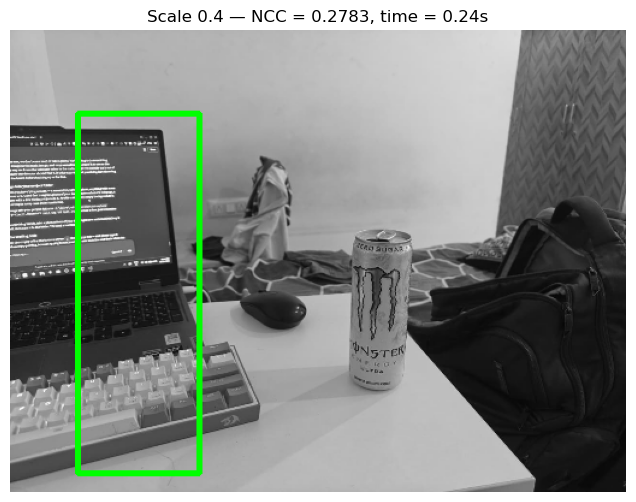

  Detection at: x=56, y=69
  Score: 0.2783


In [69]:
# Note: we still use the ORIGINAL template, which has size (299, 101)
# But the can in the scaled image is now a different size — mismatch!
score_scaled = run_experiment(scaled_gray, scaled_rgb, f"Scale {scale}")